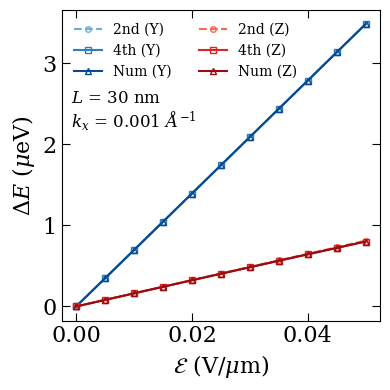

----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.005 0.348 6967.834
0.01 0.697 6967.819
0.015 1.045 6967.794
0.02 1.394 6967.76
0.025 1.742 6967.715
0.03 2.09 6967.661
0.035 2.439 6967.597
0.04 2.787 6967.523
0.045 3.135 6967.44
0.05 3.484 6967.346
----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.005 0.081 1619.317
0.01 0.162 1618.786
0.015 0.243 1617.903
0.02 0.323 1616.672
0.025 0.404 1615.098
0.03 0.484 1613.189
0.035 0.564 1610.951
0.04 0.643 1608.395
0.045 0.722 1605.53
0.05 0.801 1602.367


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
#                      GLOBAL SETTINGS
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [4, 4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                      SPLITTING PLOT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.05

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]
split_pb_2nd_y = datay_pb[:, 2]
split_pb_4th_y = datay_pb[:, 3]
split_num_y = datay_num[:, 3]



dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]
split_pb_2nd_z = dataz_pb[:, 2]
split_pb_4th_z = dataz_pb[:, 3]
split_num_z = dataz_num[:, 3]

# Color maps
cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

# Pick 3 shades (light → dark)
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ==============================================================
#                      PLOT
# ==============================================================

fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, split_pb_2nd_y, 'o--', color=blue_colors[0],
        label="2nd (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_y, 's-', color=blue_colors[1],
        label="4th (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_y, '^-', color=blue_colors[2],
        label="Num (Y)", markersize=4, markerfacecolor='None')


# Z direction (Reds)
ax.plot(Efield, split_pb_2nd_z, 'o--', color=red_colors[0],
        label="2nd (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_z, 's-', color=red_colors[1],
        label="4th (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_z, '^-', color=red_colors[2],
        label="Num (Z)", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=2, fontsize = 10)
ax.text(0.03,0.62,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.7,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)


# Labels
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.set_ylabel(r"$\Delta E$ ($\mu$eV)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
# plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
# plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_y[i].round(3), (split_num_y[i]/(Efield[i]*kx*10)).round(3))

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_z[i].round(3), (split_num_z[i]/(Efield[i]*kx*10)).round(3))

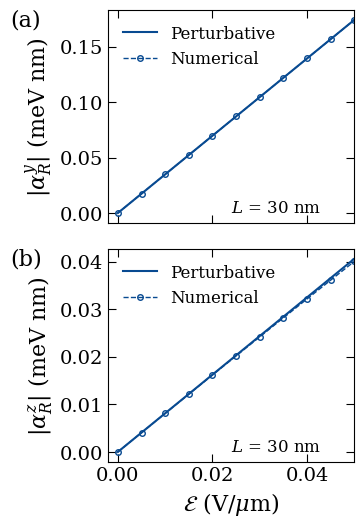

In [3]:

# ==============================================================
#                      RASHBA COEFFICIENT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.05


datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_y.dat", skiprows=1)

Efield_y = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]

Efield_y_num = datay_num[:, 0]
delE_y_num = datay_num[:, 3]
# Delta E = 2 |alpha| kx; micro-eV angstrom -> meV nm.
alpha_y_num = np.abs(delE_y_num) / (2 * abs(kx)) / 1e4


dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_z.dat", skiprows=1)

Efield_z = dataz_pb[:, 0]
Efield = Efield_z
alpha_z = dataz_pb[:, 1]
Efield_z_num = dataz_num[:, 0]
delE_z_num = dataz_num[:, 3]
alpha_z_num = np.abs(delE_z_num) / (2 * abs(kx)) / 1e4

# 2 x 1 array: (a) Y above (b) Z, sharing the electric-field axis
fig, axes = plt.subplots(2, 1, figsize=(4, 5.4), sharex=True)
for ax, (panel, electric_field, alpha, electric_field_num, alpha_num, color) in zip(axes, [
    ("(a)", Efield_y, alpha_y, Efield_y_num, alpha_y_num, blue_colors[2]),
    ("(b)", Efield_z, alpha_z, Efield_z_num, alpha_z_num, blue_colors[2]),
]):
    # Perturbative coefficients: eV angstrom -> meV nm.
    ax.plot(electric_field, np.abs(alpha) * 1e2, '-', color=color,
            label="Perturbative", linewidth=1.5)
    ax.plot(electric_field_num, alpha_num, 'o--', color=color,
            label="Numerical", markersize=4, markerfacecolor='none', linewidth=1)
    ax.legend(frameon=False, ncol=1, fontsize=12)
    ax.text(0.5, 0.05, f"$L$ = {int(L/10)} nm",
            transform=ax.transAxes, fontsize=12)
    ax.text(-0.4, 0.9, panel, transform=ax.transAxes,
            fontsize=16, va='bottom', ha='left')
    ax.set_xlim(-0.002,0.05)
    
    ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=14)

axes[0].set_ylabel(r"$|\alpha^y_R|$ (meV nm)", fontsize=16)
axes[1].set_ylabel(r"$|\alpha^z_R|$ (meV nm)", fontsize=16)
axes[1].set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=16)
# axes[1].set_xticks([0,0.05,0.1])
fig.tight_layout(h_pad=1.5)
for extension in ("svg", "pdf"):
    fig.savefig(f"alpha_2x1_N{N}_L{L}_kx{kx}.{extension}",
                dpi=300, bbox_inches='tight')
plt.show()

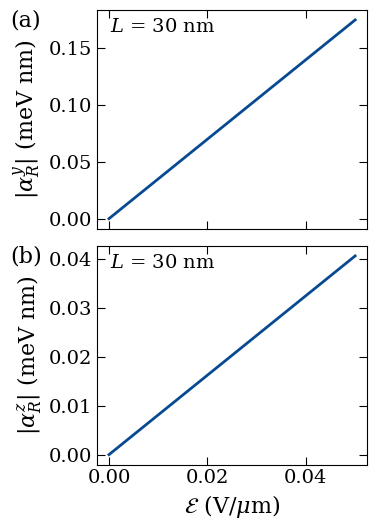

In [4]:
# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [4, 5.4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ======= CREATE 1x2 GRID =======
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True)

# --- Left Plot: Y Direction ---
ax1.plot(Efield, alpha_y * 1e2, 
         '-', 
         color=blue_colors[2],
         label=r"$\alpha_y$",
         linewidth=2, 
        #  markersize=5, 
        #  markerfacecolor='None'
         )
ax1.set_ylabel(r"$|\alpha_R^y|$ (meV nm)", fontsize=16)

# --- Right Plot: Z Direction ---
ax2.plot(Efield, alpha_z * 1e2, 
         '-', 
         color=blue_colors[2],
         label=r"$\alpha_z$",
         linewidth=2, 
        #  markersize=5, 
        #  markerfacecolor='None'
         )
ax2.set_ylabel(r"$|\alpha_R^z|$ (meV nm)", fontsize=16)

# --- Common Formatting ---
for ax in [ax1, ax2]:
    
    ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=14)
ax2.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=16)
# --- Text annotations ---
# ax1.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax1.transAxes, fontsize=14)
ax1.text(0.05, 0.9, f"$L$ = {int(L/10)} nm", transform=ax1.transAxes, fontsize=14)
# ax1.text(0.05, 0.9, r"$\mathcal{E}$ || $y$", transform=ax1.transAxes, fontsize=14)

# ax2.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax2.transAxes, fontsize=14)
ax2.text(0.05, 0.9, f"$L$ = {int(L/10)} nm", transform=ax2.transAxes, fontsize=14)
# ax2.text(0.05, 0.9, r"$\mathcal{E}$ || $z$", transform=ax2.transAxes, fontsize=14)

# --- Panel labels (a), (b) ---
ax1.text(-0.32, 1., "(a)", transform=ax1.transAxes,
         fontsize=16, va='top')

ax2.text(-0.32, 1., "(b)", transform=ax2.transAxes,
         fontsize=16, va='top')

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)  # <-- increase spacing here

# Save
# plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.png", dpi=300)
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.pdf", dpi=300)
plt.show()